# NZSL Report — Visual Generation

Standalone notebook for generating all figures used in the report.  
Run the **Setup** cell first, then each figure cell independently.  
All figures are saved to `../outputs/figures/`.

---

## Setup — Load pipeline outputs

Reads the CSVs written by `nzsl_fingerspelling_pipeline_full.ipynb`.  
All figure cells below depend on `df_report` and `df_dataset`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUTS_DIR = Path('../outputs')
FIG_DIR     = OUTPUTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load pipeline outputs ─────────────────────────────────────────────────────
# extraction_report.csv — per-class extraction stats (class, found, extracted,
#   drop_wrong_count, drop_no_hands, hand_group, success_pct, ...)
df_report = pd.read_csv(OUTPUTS_DIR / 'extraction_report.csv')

# dataset.csv — full feature table (f_0..f_507, label, hand_group, detected_hands)
# Only load the metadata columns to avoid reading 511 columns unnecessarily.
df_dataset = pd.read_csv(
    OUTPUTS_DIR / 'dataset.csv',
    usecols=['label', 'hand_group', 'detected_hands']
)

# ── Quick summary ─────────────────────────────────────────────────────────────
two  = df_report[df_report['hand_group'] == 'two_hand']
one  = df_report[df_report['hand_group'] == 'one_hand']

TOTAL_SCANNED  = int(df_report['found'].sum())
TOTAL_CLASSES  = len(df_report)
TOTAL_EXTRACTED= int(df_report['extracted'].sum())
TWO_CLASSES    = len(two)
TWO_SAMPLES    = int(two['extracted'].sum())
ONE_CLASSES    = len(one)
ONE_SAMPLES    = int(one['extracted'].sum())

print(f'Pipeline outputs loaded from: {OUTPUTS_DIR.resolve()}')
print(f'  Total images scanned : {TOTAL_SCANNED:,}')
print(f'  Total classes        : {TOTAL_CLASSES}')
print(f'  Total extracted      : {TOTAL_EXTRACTED:,}')
print(f'  Two-hand: {TWO_CLASSES} classes, {TWO_SAMPLES:,} samples')
print(f'  One-hand: {ONE_CLASSES} classes, {ONE_SAMPLES:,} samples')
print(f'Figures will save to   : {FIG_DIR.resolve()}')

Pipeline outputs loaded from: C:\Users\harma\OneDrive - AUT University\IDE_Workspace\aut_projects\nzsl-fingerspelling\outputs
  Total images scanned : 34,000
  Total classes        : 34
  Total extracted      : 27,620
  Two-hand: 23 classes, 16,989 samples
  One-hand: 11 classes, 10,631 samples
Figures will save to   : C:\Users\harma\OneDrive - AUT University\IDE_Workspace\aut_projects\nzsl-fingerspelling\outputs\figures


C:\Users\harma\AppData\Local\Temp\ipykernel_16348\1101687001.py:20: DtypeWarning: Columns (508) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dataset = pd.read_csv(


---
## Figure 1 — System Pipeline Diagram

End-to-end pipeline overview. Stage labels that contain counts (total images, class counts,
sample counts per branch) are populated directly from the pipeline output files — no hardcoding.

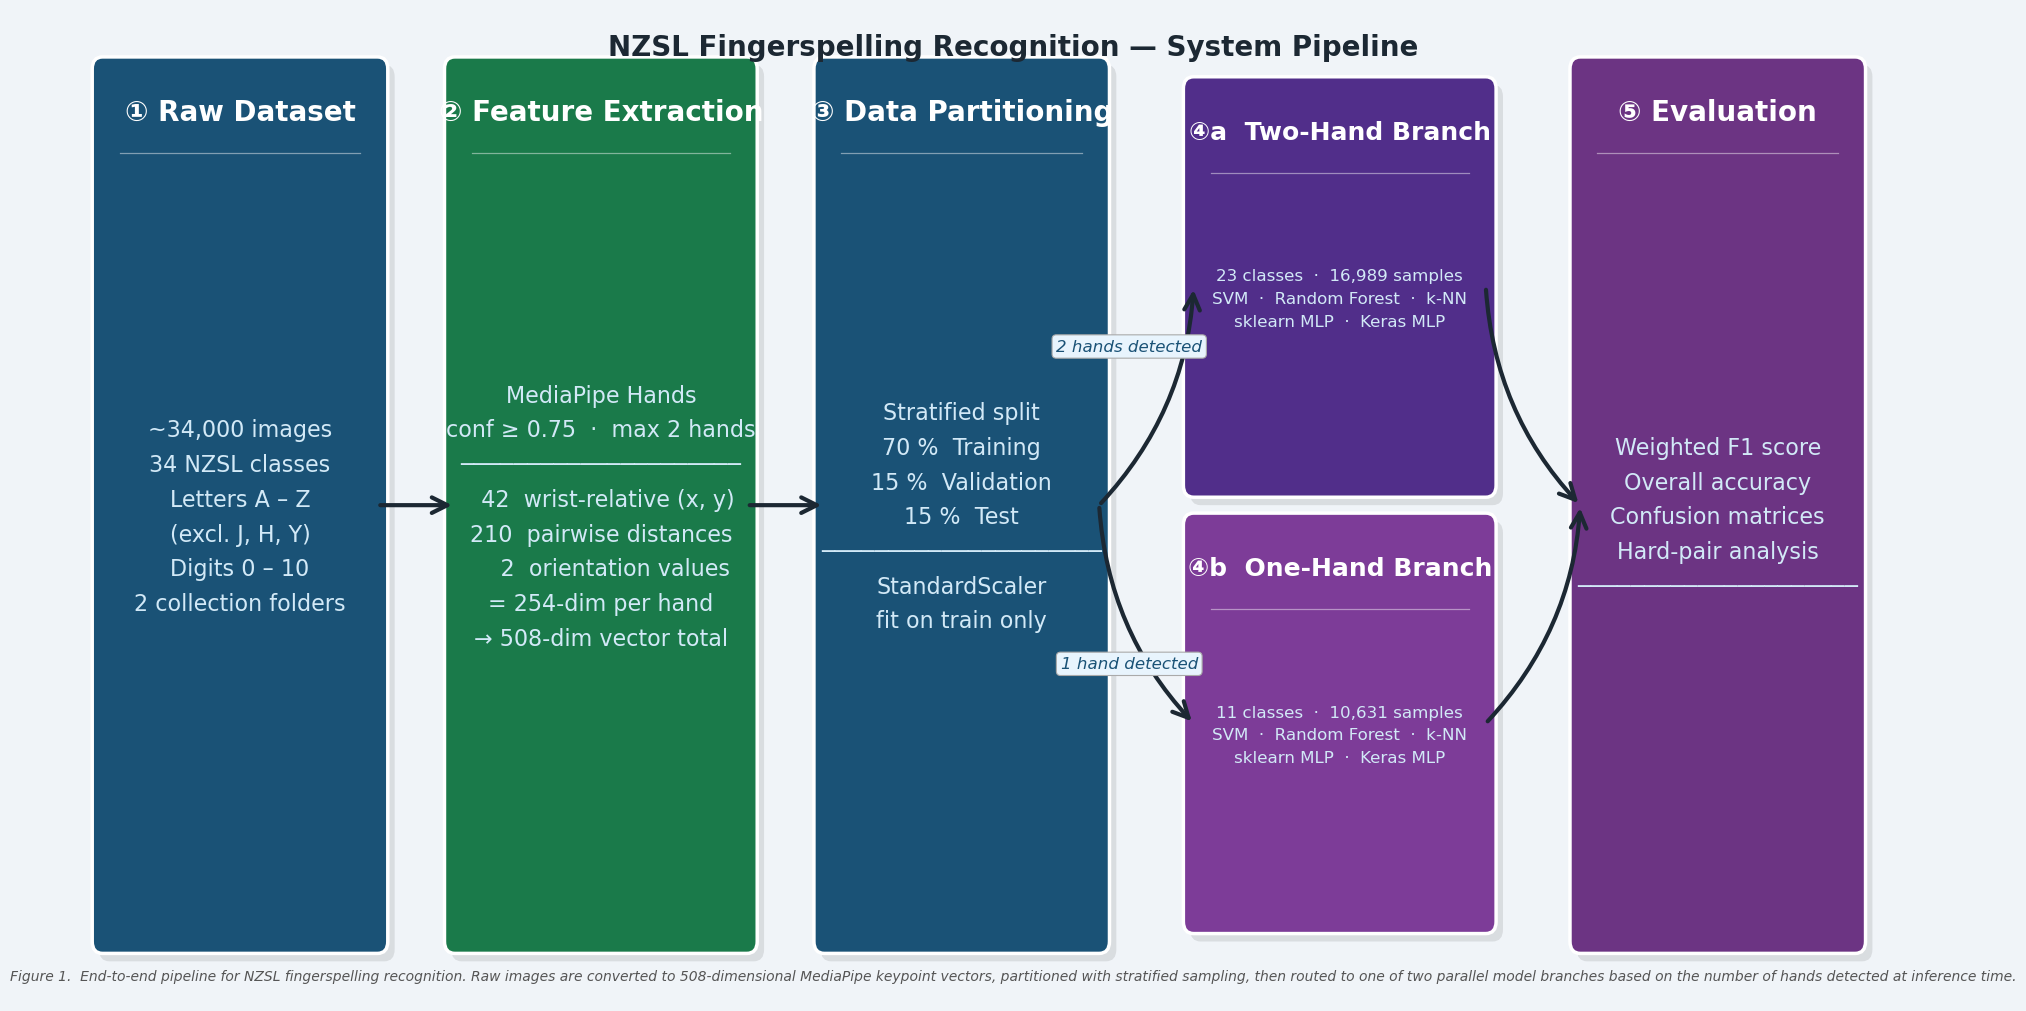

Saved → ..\outputs\figures\figure1_pipeline.png


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 1 — NZSL System Pipeline
# ─────────────────────────────────────────────────────────────────────────────

# ── Dynamic labels from pipeline outputs ─────────────────────────────────────
s1_lines = [
    f'~{TOTAL_SCANNED:,} images',
    f'{TOTAL_CLASSES} NZSL classes',
    'Letters A – Z',
    '(excl. J, H, Y)',
    'Digits 0 – 10',
    '2 collection folders',
]
s4a_lines = [
    f'{TWO_CLASSES} classes  ·  {TWO_SAMPLES:,} samples',
    'SVM  ·  Random Forest  ·  k-NN',
    'sklearn MLP  ·  Keras MLP',
]
s4b_lines = [
    f'{ONE_CLASSES} classes  ·  {ONE_SAMPLES:,} samples',
    'SVM  ·  Random Forest  ·  k-NN',
    'sklearn MLP  ·  Keras MLP',
]

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
ax.set_xlim(0, 22)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F0F4F8')

C = dict(
    data  = '#1A5276',
    feat  = '#1A7A4A',
    two   = '#512E8A',
    one   = '#7D3C98',
    evl   = '#6C3483',
    arrow = '#1C2833',   # near-black — clearly visible against all box colours
)

# ── Stage geometry ────────────────────────────────────────────────────────────
X              = [2.0, 6.2, 10.4, 14.8, 19.2]
CY             = 5.0
W_MAIN, H_MAIN = 3.2, 8.8
W_BR,   H_BR   = 3.4, 4.0
CY_TOP, CY_BOT = 7.2, 2.8

# ── Helpers ───────────────────────────────────────────────────────────────────
def stage(cx, cy, w, h, title, lines, fc, tfs=20.0, bfs=16.0):
    # Shadow
    ax.add_patch(FancyBboxPatch(
        (cx - w/2 + 0.08, cy - h/2 - 0.08), w, h,
        boxstyle='round,pad=0.12',
        facecolor='#00000018', edgecolor='none', zorder=2))
    # Box fill
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle='round,pad=0.12',
        facecolor=fc, edgecolor='white', linewidth=2.5, zorder=3))
    # Header divider
    sep_y = cy + h/2 - 0.85
    ax.plot([cx - w/2 + 0.2, cx + w/2 - 0.2], [sep_y, sep_y],
            color='white', lw=0.9, alpha=0.45, zorder=4)
    # Title
    ax.text(cx, cy + h/2 - 0.44, title,
            ha='center', va='center', fontsize=tfs,
            fontweight='bold', color='white', zorder=5)
    # Body
    ax.text(cx, cy - 0.12, '\n'.join(lines),
            ha='center', va='center', fontsize=bfs,
            color='#D2E9F7', linespacing=1.65, zorder=5)


def arrow_straight(x1, y1, x2, y2):
    """Horizontal arrow between two boxes (drawn above all box layers)."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle='->', color=C['arrow'],
                    lw=3.0, mutation_scale=28,
                    connectionstyle='arc3,rad=0'),
                zorder=10)


def arrow_elbow(x1, y1, x2, y2, rad=0.18):
    """Curved elbow arrow for branching/merging — avoids angle intersection errors."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle='->', color=C['arrow'],
                    lw=3.0, mutation_scale=28,
                    connectionstyle=f'arc3,rad={rad}'),
                zorder=10)


def tag(x, y, text):
    ax.text(x, y, text, ha='center', va='center', fontsize=12,
            color='#1A5276', style='italic', zorder=11,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#E8F4FD',
                      edgecolor='#AAAAAA', linewidth=0.8))

# ── Draw stages ───────────────────────────────────────────────────────────────
stage(X[0], CY, W_MAIN, H_MAIN, '① Raw Dataset', s1_lines, C['data'])

stage(X[1], CY, W_MAIN + 0.2, H_MAIN, '② Feature Extraction',
      ['MediaPipe Hands',
       'conf ≥ 0.75  ·  max 2 hands',
       '─' * 21,
       '  42  wrist-relative (x, y)',
       '210  pairwise distances',
       '    2  orientation values',
       '= 254-dim per hand',
       '→ 508-dim vector total'],
      C['feat'])

stage(X[2], CY, W_MAIN, H_MAIN, '③ Data Partitioning',
      ['Stratified split',
       '70 %  Training',
       '15 %  Validation',
       '15 %  Test',
       '─' * 21,
       'StandardScaler',
       'fit on train only'],
      C['data'])

stage(X[3], CY_TOP, W_BR, H_BR,
      '④a  Two-Hand Branch', s4a_lines, C['two'], tfs=18, bfs=12.0)

stage(X[3], CY_BOT, W_BR, H_BR,
      '④b  One-Hand Branch', s4b_lines, C['one'], tfs=18, bfs=12.0)

stage(X[4], CY, W_MAIN, H_MAIN, '⑤ Evaluation',
      ['Weighted F1 score',
       'Overall accuracy',
       'Confusion matrices',
       'Hard-pair analysis',
       '─' * 21],
      C['evl'])

# ── Arrows (zorder=10 — always above boxes) ───────────────────────────────────
# Straight: ① → ②
arrow_straight(X[0] + W_MAIN/2,          CY,
               X[1] - (W_MAIN + 0.2)/2,  CY)

# Straight: ② → ③
arrow_straight(X[1] + (W_MAIN + 0.2)/2,  CY,
               X[2] - W_MAIN/2,           CY)

# Elbow: ③ → ④a (fork up)
arrow_elbow(X[2] + W_MAIN/2, CY,    X[3] - W_BR/2, CY_TOP)

# Elbow: ③ → ④b (fork down)
arrow_elbow(X[2] + W_MAIN/2, CY,    X[3] - W_BR/2, CY_BOT)

# Elbow: ④a → ⑤ (merge down)
arrow_elbow(X[3] + W_BR/2, CY_TOP,  X[4] - W_MAIN/2, CY)

# Elbow: ④b → ⑤ (merge up)
arrow_elbow(X[3] + W_BR/2, CY_BOT,  X[4] - W_MAIN/2, CY)

# ── Routing tags ─────────────────────────────────────────────────────────────
tag(12.35, 6.6, '2 hands detected')
tag(12.35, 3.4, '1 hand detected')

# ── Title & caption ───────────────────────────────────────────────────────────
ax.text(11, 9.62,
        'NZSL Fingerspelling Recognition — System Pipeline',
        ha='center', va='center', fontsize=20,
        fontweight='bold', color='#1C2833')

ax.text(11, 0.25,
        'Figure 1.  End-to-end pipeline for NZSL fingerspelling recognition. '
        'Raw images are converted to 508-dimensional MediaPipe keypoint vectors, '
        'partitioned with stratified sampling, then routed to one of two parallel '
        'model branches based on the number of hands detected at inference time.',
        ha='center', va='center', fontsize=10,
        color='#555555', style='italic')

out1 = FIG_DIR / 'figure1_pipeline.png'
plt.tight_layout(pad=0.3)
plt.savefig(out1, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved → {out1}')

---
## Figure 2 — Per-Class Image Yield After Feature Extraction

All values read directly from `outputs/extraction_report.csv` — nothing hardcoded.

**Layout:** Two stacked panels (two-hand top / one-hand bottom) to avoid cramming 34 classes into one row.  
Outlier annotations use **three alternating height levels** so arrows for consecutive bars never overlap.

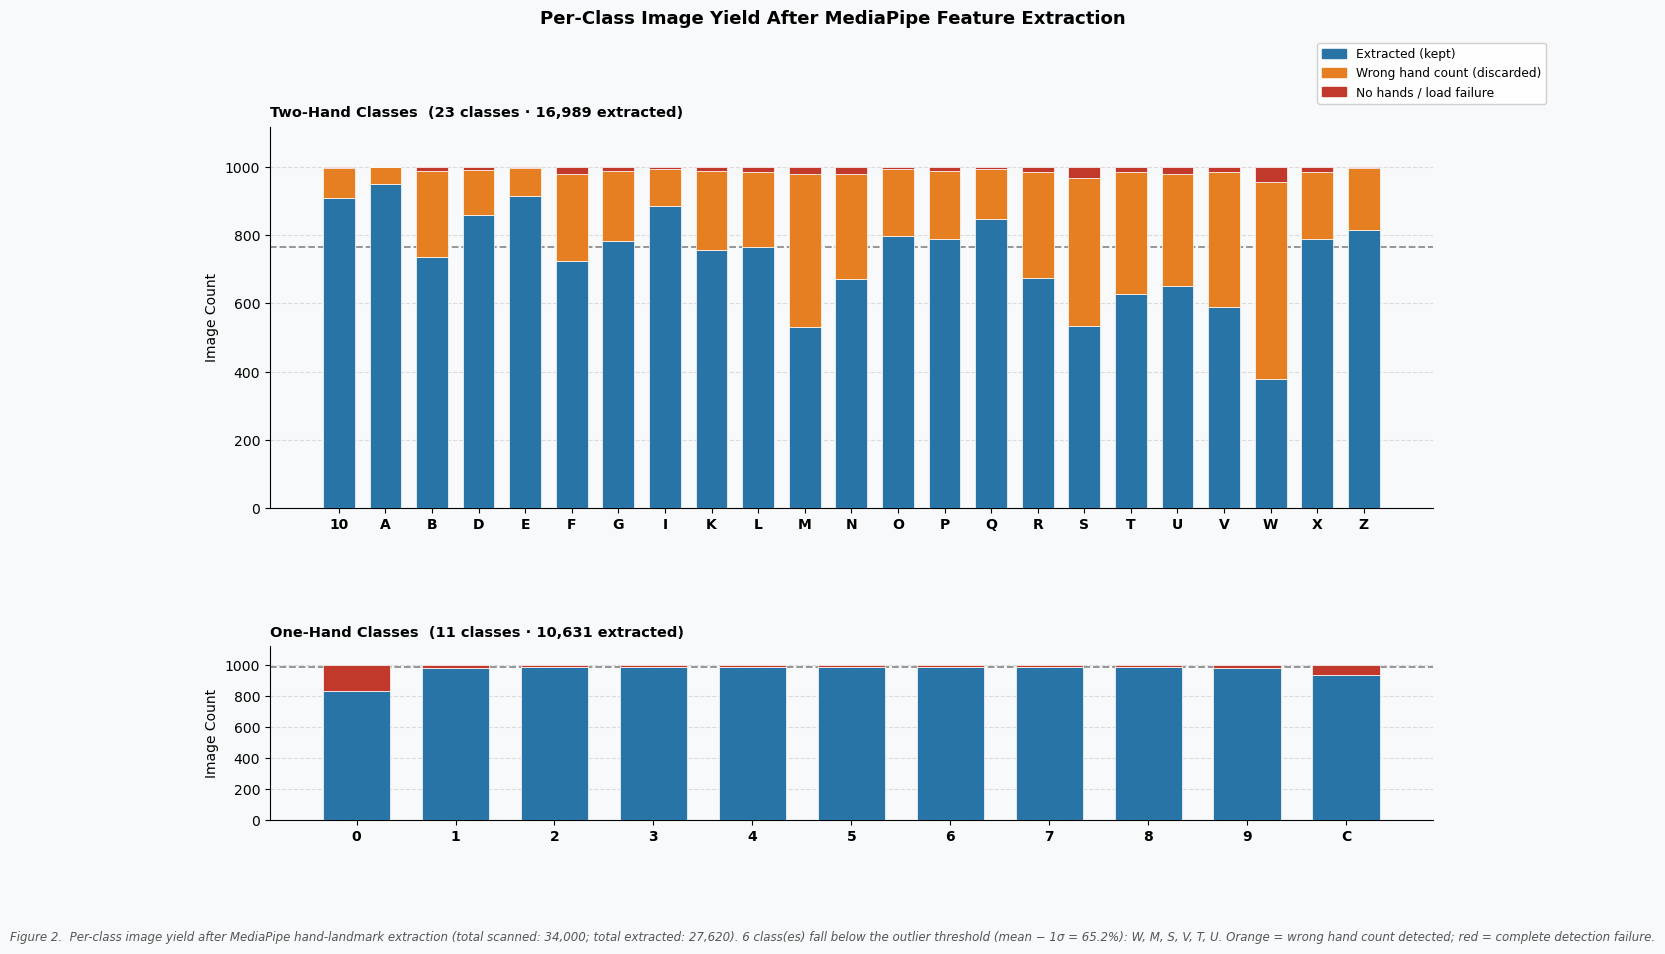

Saved → ..\outputs\figures\figure2_class_distribution.png


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  Figure 2 — Per-Class Image Yield After MediaPipe Feature Extraction
#  Two-panel layout: two-hand (top) | one-hand (bottom)
#  Data source: outputs/extraction_report.csv  — no hardcoded values
# ─────────────────────────────────────────────────────────────────────────────

# ── Prepare per-group data (alphabetical within each group) ───────────────────
df_two_s = df_report[df_report['hand_group'] == 'two_hand'].sort_values('class').reset_index(drop=True)
df_one_s = df_report[df_report['hand_group'] == 'one_hand'].sort_values('class').reset_index(drop=True)

# Global outlier threshold: mean − 1σ (used only for caption text, not annotations)
mean_suc  = df_report['success_pct'].mean()
std_suc   = df_report['success_pct'].std()
threshold = mean_suc - std_suc

# ── Colours ───────────────────────────────────────────────────────────────────
COL_KEPT  = '#2874A6'   # blue   — extracted & kept
COL_WRONG = '#E67E22'   # orange — wrong hand count discarded
COL_NONE  = '#C0392B'   # red    — no hands / load failure
COL_MED   = '#555555'   # grey   — median dashed line

# ── Helper: draw one panel ────────────────────────────────────────────────────
def draw_panel(ax, df_grp, panel_title, show_legend=False):
    labels    = df_grp['class'].tolist()
    extracted = df_grp['extracted'].values
    wrong_ct  = df_grp['drop_wrong_count'].values
    hard_fail = (df_grp['drop_no_hands'] + df_grp['drop_load_fail']).values
    max_found = int(df_grp['found'].max())
    median_v  = df_grp['extracted'].median()

    x, bar_w = np.arange(len(labels)), 0.68

    ax.bar(x, extracted, bar_w, color=COL_KEPT,
           label='Extracted (kept)', edgecolor='white', lw=0.5, zorder=3)
    ax.bar(x, wrong_ct, bar_w, bottom=extracted, color=COL_WRONG,
           label='Wrong hand count (discarded)', edgecolor='white', lw=0.5, zorder=3)
    ax.bar(x, hard_fail, bar_w, bottom=extracted + wrong_ct, color=COL_NONE,
           label='No hands / load failure', edgecolor='white', lw=0.5, zorder=3)

    ax.axhline(median_v, color=COL_MED, lw=1.3, ls='--', alpha=0.65,
               label=f'Group median ({median_v:.0f})')

    # ── Panel styling ─────────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax.set_ylabel('Image Count', fontsize=10)
    ax.set_ylim(0, max_found * 1.12)
    ax.set_title(panel_title, fontsize=10.5, fontweight='bold', loc='left', pad=7)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#F8F9FA')
    if show_legend:
        ax.legend(fontsize=8.5, loc='upper right', framealpha=0.92,
                  ncol=2, columnspacing=1.0)

# ── Build the two-panel figure ────────────────────────────────────────────────
fig2, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15, 9),
    gridspec_kw={'height_ratios': [2.2, 1], 'hspace': 0.50}
)
fig2.patch.set_facecolor('#F8F9FA')

draw_panel(
    ax_top, df_two_s,
    f'Two-Hand Classes  ({TWO_CLASSES} classes · {TWO_SAMPLES:,} extracted)',
    show_legend=False
)
draw_panel(
    ax_bot, df_one_s,
    f'One-Hand Classes  ({ONE_CLASSES} classes · {ONE_SAMPLES:,} extracted)',
    show_legend=False
)

# ── Figure-level legend (top-right) ───────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COL_KEPT,  label='Extracted (kept)'),
    mpatches.Patch(color=COL_WRONG, label='Wrong hand count (discarded)'),
    mpatches.Patch(color=COL_NONE,  label='No hands / load failure'),
]
fig2.legend(
    handles=legend_handles,
    fontsize=8.8, framealpha=0.92,
    loc='upper right', bbox_to_anchor=(0.98, 0.98)
)

# ── Overall title ─────────────────────────────────────────────────────────────
fig2.suptitle(
    'Per-Class Image Yield After MediaPipe Feature Extraction',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Dynamic figure caption ────────────────────────────────────────────────────
all_out = df_report[df_report['success_pct'] < threshold].sort_values('success_pct')
all_out_names = ', '.join(all_out['class'].tolist())
n_out = len(all_out)

fig2.text(
    0.5, -0.025,
    f'Figure 2.  Per-class image yield after MediaPipe hand-landmark extraction '
    f'(total scanned: {TOTAL_SCANNED:,}; total extracted: {TOTAL_EXTRACTED:,}). '
    f'{n_out} class(es) fall below the outlier threshold '
    f'(mean − 1σ = {threshold:.1f}%): {all_out_names}. '
    f'Orange = wrong hand count detected; red = complete detection failure.',
    ha='center', fontsize=8.5, color='#555', style='italic'
)

out2 = FIG_DIR / 'figure2_class_distribution.png'
plt.savefig(out2, dpi=200, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print(f'Saved → {out2}')

---
*Add further figure cells below as needed — e.g., Figure 3 (confusion matrices), Figure 4 (training curves), Figure 5 (feature importance).*